In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
from pathlib import Path

blog_visuals = Path("../visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

def export_figure(fig, filename, dpi=220, width_px=None, aspect=None, tight=False, pad_inches=0.08):
    if width_px is not None and aspect is not None:
        fig.set_size_inches(width_px / dpi, (width_px * aspect) / dpi)
    out = blog_visuals / filename
    bbox = "tight" if tight else None
    fig.savefig(out, dpi=dpi, bbox_inches=bbox, pad_inches=pad_inches)
    print(f"Saved figure: {out.resolve()}")
    return out

def md_image(path, display_width_px=680):
    rel = path.relative_to(blog_visuals.parent)
    print(f"<img class=\"post-figure\" src=\"{rel.as_posix()}\" width=\"{display_width_px}\" />")

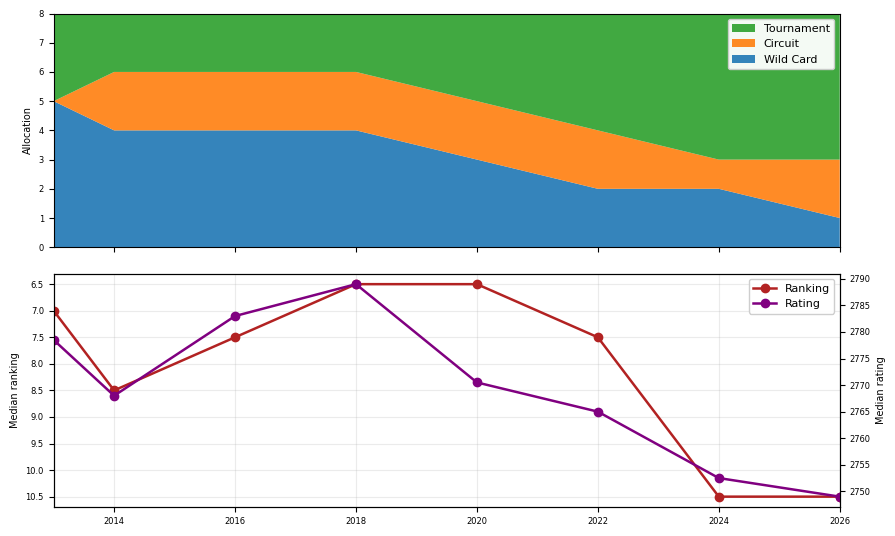

In [30]:
pathways = pd.read_csv('data/pathways.csv')
ratings = pd.read_csv('data/ratings.csv')

median_by_year = ratings.groupby('year', as_index=False)[['ranking', 'rating']].median()

fig, axes = plt.subplots(2, 1, figsize=(8.8, 5.2), sharex=True, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.04, hspace=0.08)

handles = axes[0].stackplot(
    pathways['year'], pathways['wildcard'], pathways['circuit'], pathways['tournament'],
    labels=['Wild Card', 'Circuit', 'Tournament'], alpha=0.9
)
axes[0].set_ylabel('Allocation', fontsize=7)
axes[0].set_ylim(0, 8)
axes[0].set_xlim(pathways['year'].min(), pathways['year'].max())
axes[0].tick_params(axis='both', labelsize=6)
axes[0].legend(
    handles[::-1], ['Tournament', 'Circuit', 'Wild Card'],
    loc='upper right', fontsize=8,
    frameon=True, facecolor='white', edgecolor='0.8', framealpha=0.95,
)

rank_line, = axes[1].plot(
    median_by_year['year'], median_by_year['ranking'],
    marker='o', linewidth=1.8, color='firebrick'
)
ax2 = axes[1].twinx()
rating_line, = ax2.plot(
    median_by_year['year'], median_by_year['rating'],
    marker='o', linewidth=1.8, color='purple'
)

axes[1].set_ylabel('Median ranking', fontsize=7)
axes[1].invert_yaxis()
ax2.set_ylabel('Median rating', fontsize=7)
axes[1].tick_params(axis='both', labelsize=6)
ax2.tick_params(axis='y', labelsize=6)
axes[1].grid(alpha=0.25)
axes[1].legend(
    [rank_line, rating_line], ['Ranking', 'Rating'],
    loc='upper right', fontsize=8,
    frameon=True, facecolor='white', edgecolor='0.8', framealpha=0.95,
)

fig_overview = fig
plt.show()

/var/folders/yt/kn5nn59n7979w5bbz2xn24yw0000gn/T/ipykernel_79406/2309735592.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rank_data, labels=display_labels, **bp_kw)
/var/folders/yt/kn5nn59n7979w5bbz2xn24yw0000gn/T/ipykernel_79406/2309735592.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(rating_data, labels=display_labels, **bp_kw)


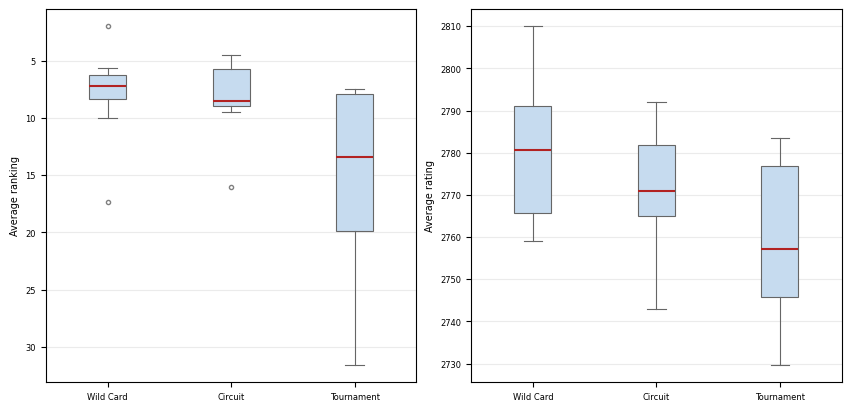

In [31]:
ratings = pd.read_csv('data/ratings.csv')

wild_card_labels = ['rating', 'runnerup', 'wildcard']
circuit_labels = ['prix', 'circuit']
tournament_labels = ['cup', 'swiss']

pathway_map = {label: 'wild_card' for label in wild_card_labels}
pathway_map.update({label: 'circuit' for label in circuit_labels})
pathway_map.update({label: 'tournament' for label in tournament_labels})

ratings['pathway_group'] = ratings['pathway'].map(pathway_map)

avg_by_year = (
    ratings
    .dropna(subset=['pathway_group'])
    .groupby(['year', 'pathway_group'], as_index=False)[['ranking', 'rating']]
    .mean()
)

group_order = ['wild_card', 'circuit', 'tournament']
display_labels = ['Wild Card', 'Circuit', 'Tournament']
rank_data = [avg_by_year.loc[avg_by_year['pathway_group'] == g, 'ranking'] for g in group_order]
rating_data = [avg_by_year.loc[avg_by_year['pathway_group'] == g, 'rating'] for g in group_order]

bp_kw = dict(
    patch_artist=True,
    boxprops=dict(facecolor='#c6dbef', linewidth=0.8, edgecolor='0.4'),
    medianprops=dict(color='firebrick', linewidth=1.5),
    whiskerprops=dict(linewidth=0.8, color='0.4'),
    capprops=dict(linewidth=0.8, color='0.4'),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='none', markeredgecolor='0.5', linewidth=0.6),
)

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.0), constrained_layout=True)

axes[0].boxplot(rank_data, labels=display_labels, **bp_kw)
axes[0].set_ylabel('Average ranking', fontsize=7)
axes[0].invert_yaxis()
axes[0].tick_params(axis='both', labelsize=6)
axes[0].grid(axis='y', alpha=0.25)

axes[1].boxplot(rating_data, labels=display_labels, **bp_kw)
axes[1].set_ylabel('Average rating', fontsize=7)
axes[1].tick_params(axis='both', labelsize=6)
axes[1].grid(axis='y', alpha=0.25)

fig_pathways_boxplots = fig
plt.show()

In [32]:
overview_path = export_figure(fig_overview, "pathway-overview.png", width_px=1200, aspect=0.59)
boxplots_path = export_figure(fig_pathways_boxplots, "pathway-boxplots.png", width_px=1200, aspect=0.48)
md_image(overview_path)
md_image(boxplots_path)

Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.04 Chess Candidates/visuals/pathway-overview.png
Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.04 Chess Candidates/visuals/pathway-boxplots.png
<img class="post-figure" src="visuals/pathway-overview.png" width="680" />
<img class="post-figure" src="visuals/pathway-boxplots.png" width="680" />
